## Distance matrix between cities module 

In [8]:
# Necessary import
import json
import pandas as pd
import numpy as np
from shapely.geometry import shape
from shapely.geometry import Point
from scipy.spatial.distance import pdist, squareform
from tqdm import tqdm
from geopy.distance import geodesic
from multiprocessing import Pool
from Worker import worker

## Step 1 - load json file and get commune coordinates

In [9]:
# Load the GeoJSON map of French (Métropolitaine) communes
communes_geojson_path = "map/communes.geojson"  # Update with your path
with open(communes_geojson_path) as f:
    communes_geojson = json.load(f)

In [10]:
# Extract geometries and calculate centroids
centroids = []
communes_code = []

for feature in communes_geojson['features']:
    commune_geom = shape(feature['geometry'])
    centroids.append((float(commune_geom.centroid.x), float(commune_geom.centroid.y)))
    communes_code.append(feature['properties']['code'])
    
# Create a DataFrame from the centroids
centroids = np.array(centroids)
communes_code_df = pd.Series(communes_code)

In centroids array, at row i you have the coordinates of commune with code communes_code_df[i]

In [11]:
print(centroids)
print(communes_code_df)

[[ 3.29821749 46.15938914]
 [ 6.02999713 44.74464471]
 [ 0.47655593 45.55395977]
 ...
 [-0.38117942 44.44981574]
 [-0.68510557 44.37241594]
 [ 2.34280442 48.85661136]]
0        03252
1        05039
2        16203
3        16372
4        24002
         ...  
35223    33533
35224    33543
35225    33547
35226    40032
35227    75056
Length: 35228, dtype: object


In [12]:
n = len(centroids)

## Step 2 : Compute distance between all cities

In [13]:
distance_matrix = pdist(centroids)

In [14]:
print(distance_matrix)

[3.07638128 2.88588265 2.85870155 ... 0.3136269  5.18072733 5.41075296]


In [15]:
# Convert the distance matrix to a DataFrame
distance_df = pd.DataFrame(distance_matrix)

To find the distance between commune code_1 and code_2 : 

1. Find their i and j index in communes_code_df :

i = communes_code_df[communes_code_df == str(code_1)].index[0]
j = communes_code_df[communes_code_df == str(code_2)].index[0]

Get element with index k in distance_matrix : (for i<j): 

 k = n * i - i * (i + 1) // 2 + (j - i - 1)

# Graph creation 

In [ ]:
import networkx as nx

# Create a graph object
G = nx.Graph()

# Add nodes (communes) with their coordinates as attributes
for commune, coords in centroid_df.iterrows():
    G.add_node(commune, coords=(coords['longitude'], coords['latitude']))

# Add edges (distances between communes)
for edge in edges:
    G.add_edge(edge[0], edge[1], weight=edge[2])

# Display the number of nodes and edges
print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph created with 200 nodes and 19900 edges.


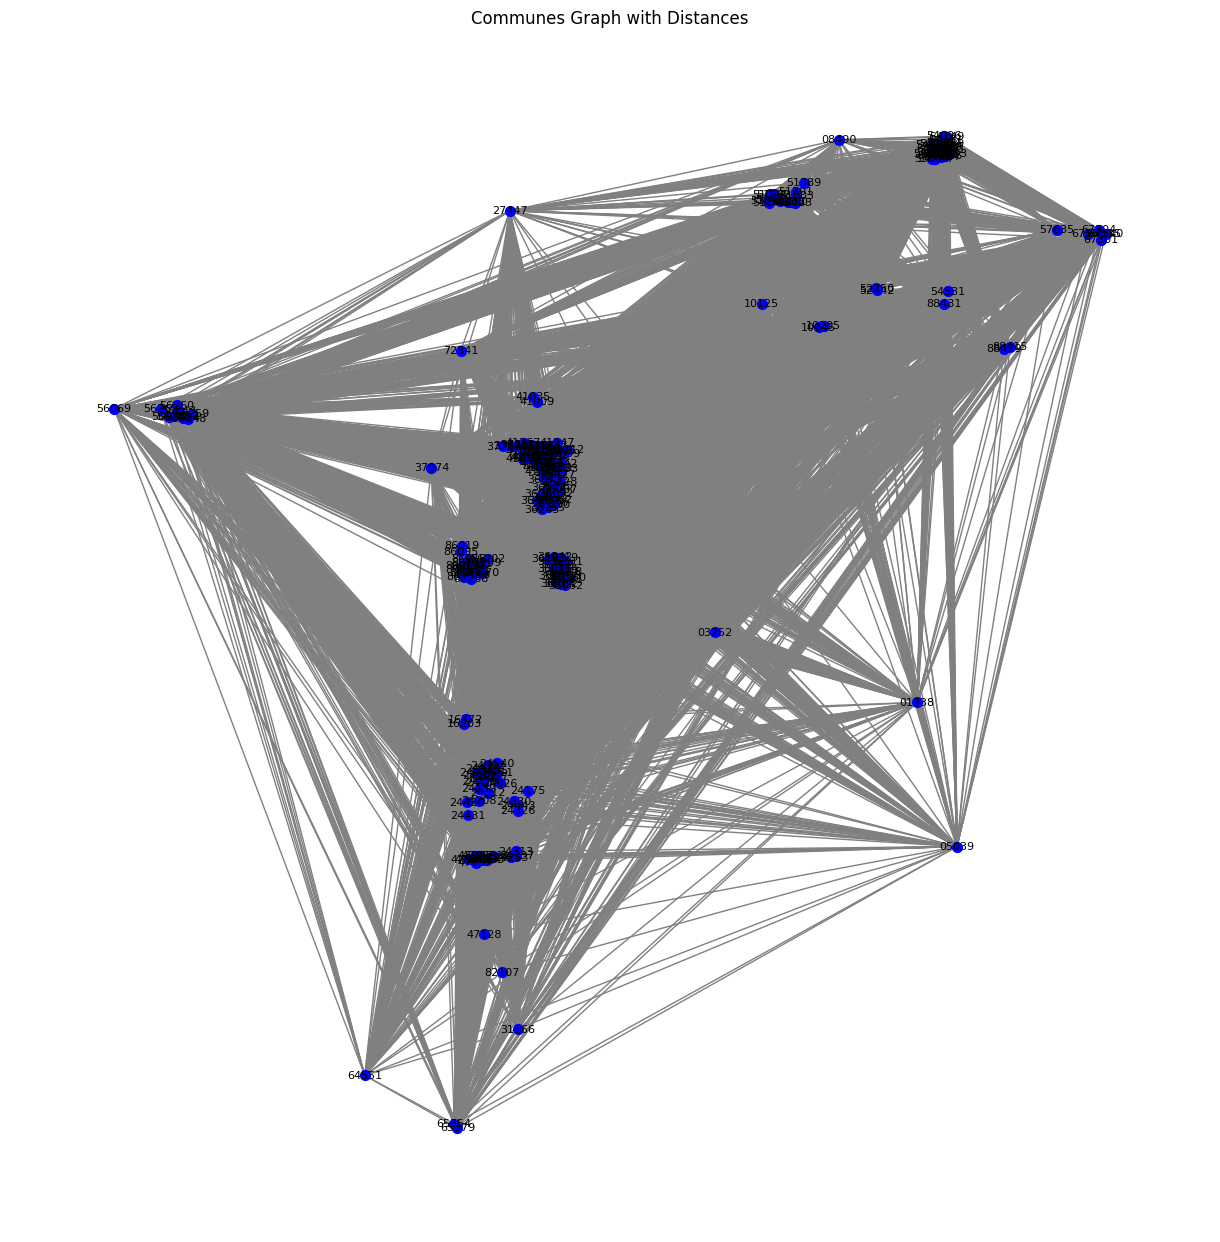

In [ ]:
import matplotlib.pyplot as plt

# Plot the graph
plt.figure(figsize=(12, 12))

# Generate positions for nodes based on coordinates (latitude and longitude)
pos = {commune: G.nodes[commune]['coords'] for commune in G.nodes}

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=50, font_size=8, node_color='blue', edge_color='gray')

plt.title("Communes Graph with Distances")
plt.show()
